### Magnitude estimation
Edit the numbers marked `👈` and re-run.

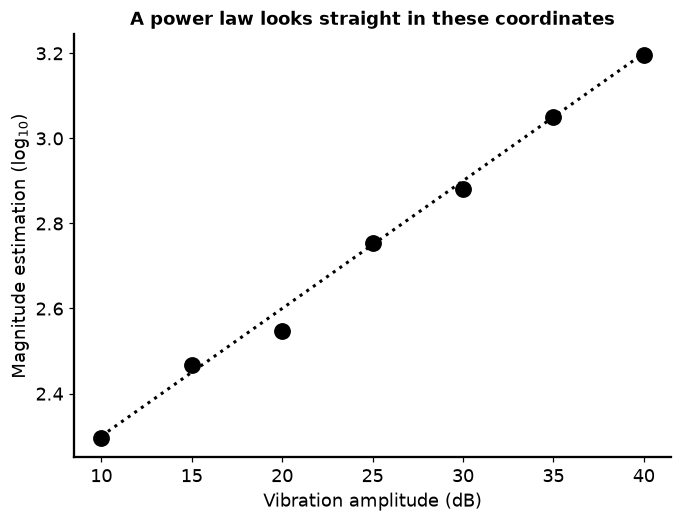

In [1]:
# (hide matplotlib's harmless one-time "building the font cache" message)
import logging; logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 12, "axes.titlesize": 12,
    "axes.titleweight": "semibold", "axes.linewidth": 1.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "legend.frameon": False,
})
rng = np.random.default_rng()

# Magnitude estimation (after Stevens): observers report a number for the perceived
# amplitude of a vibration felt through a metal rod.
rng = np.random.default_rng()
dBs = np.arange(10, 41, 5)                 # vibration amplitude, in dB
amplitudes = 10.0 ** (dBs / 20)

exponent = 0.6                              # 👈 Stevens' power-law exponent
perceived = amplitudes ** exponent
perceived = perceived + rng.standard_normal((28, dBs.size))   # 28 estimates, gaussian noise
estimate = np.round(perceived * 100)       # observers report any number, on any scale

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(dBs, np.log10(estimate.mean(axis=0)), 100, color="k", zorder=3)
ax.plot(dBs, dBs * 0.03 + 2, "k:", lw=2)   # a straight reference line
ax.set(xlabel="Vibration amplitude (dB)", ylabel="Magnitude estimation (log$_{10}$)",
       title="A power law looks straight in these coordinates")
plt.show()
